# Валидация, подбор гиперпараметров и отбор признаков

## 1. Загрузка данных и библиотек


In [125]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(DATA_DIR / "features_train_5class.csv")
test_df = pd.read_csv(DATA_DIR / "features_test_5class.csv")

X_full = train_df.drop(columns=["Activity"])
y_full = train_df["Activity"]
X_test = test_df.drop(columns=["Activity"])
y_test = test_df["Activity"]

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Количество признаков:", X_full.shape[1])
print("Классы:", sorted(y_full.unique()))
train_df.head()


Train: (28234, 25)
Test: (7403, 25)
Количество признаков: 24
Классы: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,Activity,x_mean,x_var,x_max,x_min,x_energy,x_zcr,x_spectral_energy,x_dominant_freq,y_mean,...,y_spectral_energy,y_dominant_freq,z_mean,z_var,z_max,z_min,z_energy,z_zcr,z_spectral_energy,z_dominant_freq
0,0,-4.023674,5.996379,1.381420,-8.853894,1331.179778,0.066667,69077.309176,1.666667,9.121709,...,305749.748270,1.333333,-0.021148,2.847448,3.982469,-2.963619,170.873724,0.133333,5127.210620,1.666667
1,0,-2.848404,7.436743,1.381420,-8.853894,933.008759,0.166667,42594.410141,1.666667,9.073091,...,310345.188450,1.666667,0.469692,1.475935,3.982469,-2.287283,101.792723,0.200000,3451.121068,2.000000
2,0,-2.405937,7.121768,2.074353,-7.020812,774.617994,0.200000,33659.373310,2.000000,8.992827,...,314242.930768,2.000000,0.292408,0.547272,1.838464,-1.589091,37.966489,0.183333,1292.930233,2.333333
3,0,-2.442894,8.621051,2.074353,-7.841844,875.326877,0.200000,37002.381597,2.000000,9.064488,...,322975.914164,2.000000,0.113756,0.531078,1.662883,-1.589091,32.641117,0.150000,1002.889394,2.333333
4,0,-2.805344,8.904830,1.844126,-7.841844,1006.487037,0.183333,44362.036427,2.000000,8.856433,...,303828.209368,2.000000,-0.217010,0.363280,1.089728,-1.486269,24.622373,0.200000,823.571476,1.000000


## 2. Разделение на train, validation и test


In [126]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

split_balance = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
})

(split_balance * 100).round(2)


X_train: (22587, 24)
X_val: (5647, 24)
X_test: (7403, 24)


,train,validation,test
Activity,,,
0,8.93,8.93,8.87
1,32.07,32.07,28.07
2,5.80,5.79,4.43
3,4.66,4.66,3.58
4,48.55,48.56,55.05


### Вывод

Обучающая часть была разделена на `train` и `validation`: `22587` объектов для обучения и `5647` объектов для настройки гиперпараметров. Отдельно остается `test` на `7403` объекта.


## 3. Вспомогательные функции


In [127]:
def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def fit_and_evaluate(model, X_tr, y_tr, X_ev, y_ev):
    start_fit = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - start_fit
    train_pred = model.predict(X_tr)
    start_pred = time.perf_counter()
    eval_pred = model.predict(X_ev)
    predict_time_ms = (time.perf_counter() - start_pred) * 1000 / len(y_ev)
    train_metrics = evaluate_predictions(y_tr, train_pred)
    eval_metrics = evaluate_predictions(y_ev, eval_pred)
    result = {
        "train_accuracy": train_metrics["accuracy"],
        "train_f1_macro": train_metrics["f1_macro"],
        "eval_accuracy": eval_metrics["accuracy"],
        "eval_precision_macro": eval_metrics["precision_macro"],
        "eval_recall_macro": eval_metrics["recall_macro"],
        "eval_f1_macro": eval_metrics["f1_macro"],
        "fit_time_sec": fit_time,
        "predict_time_ms": predict_time_ms,
    }
    return result, eval_pred


def make_lr_model(C=1.0, polynomial_degree=1, random_state=42):
    steps = []
    if polynomial_degree > 1:
        steps.append(("poly", PolynomialFeatures(degree=polynomial_degree, include_bias=False)))
    steps.extend([
        ("scaler", StandardScaler()),
        ("model", OneVsRestClassifier(LogisticRegression(
            C=C,
            solver="lbfgs",
            class_weight="balanced",
            random_state=random_state,
            max_iter=1000,
        ))),
    ])
    return Pipeline(steps)


def make_mlp_model(hidden_layer_sizes=(128,), random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="relu",
            solver="adam",
            alpha=0.0001,
            batch_size=200,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=10,
            max_iter=200,
            random_state=random_state,
        )),
    ])


## 4. Логистическая регрессия: регуляризация


In [128]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_regularization_results = []
for C_value in C_values:
    model = make_lr_model(C=C_value, polynomial_degree=1)
    metrics, _ = fit_and_evaluate(model, X_train, y_train, X_val, y_val)
    metrics.update({"C": C_value, "lambda_approx": 1 / C_value})
    lr_regularization_results.append(metrics)
lr_regularization_df = pd.DataFrame(lr_regularization_results)
lr_regularization_df = lr_regularization_df[["C", "lambda_approx", "train_accuracy", "eval_accuracy", "train_f1_macro", "eval_f1_macro", "fit_time_sec", "predict_time_ms"]]
lr_regularization_df


,C,lambda_approx,train_accuracy,eval_accuracy,train_f1_macro,eval_f1_macro,fit_time_sec,predict_time_ms
0,0.001,1000.00,0.846239,0.842040,0.827848,0.824158,0.147768,0.000759
1,0.010,100.00,0.886085,0.879936,0.871105,0.862360,0.152772,0.000455
2,0.100,10.00,0.893788,0.889322,0.880787,0.873080,0.191852,0.000433
3,1.000,1.00,0.894098,0.890916,0.882224,0.875307,0.222762,0.000433
4,10.000,0.10,0.894364,0.890030,0.882889,0.875046,0.220445,0.000451
5,100.000,0.01,0.894541,0.890207,0.883402,0.875185,0.238871,0.000526


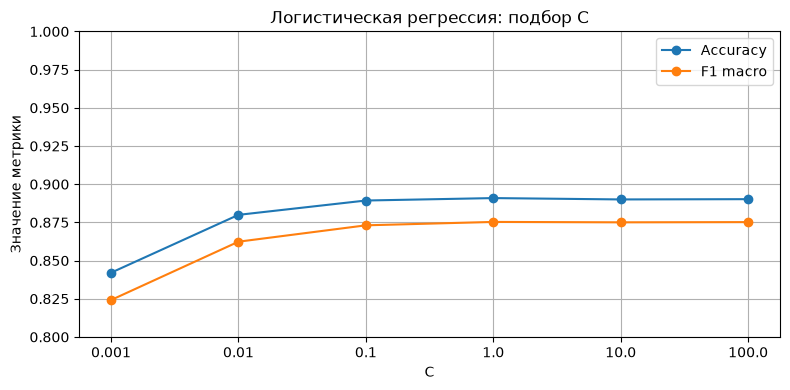

Лучшее C: 1.0


C                  1.000000
lambda_approx      1.000000
train_accuracy     0.894098
eval_accuracy      0.890916
train_f1_macro     0.882224
eval_f1_macro      0.875307
fit_time_sec       0.222762
predict_time_ms    0.000433
Name: 3, dtype: float64

In [129]:
plt.figure(figsize=(8, 4))
plt.plot(lr_regularization_df["C"].astype(str), lr_regularization_df["eval_accuracy"], marker="o", label="Accuracy")
plt.plot(lr_regularization_df["C"].astype(str), lr_regularization_df["eval_f1_macro"], marker="o", label="F1 macro")
plt.title("Логистическая регрессия: подбор C")
plt.xlabel("C")
plt.ylabel("Значение метрики")
plt.ylim(0.8, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lr_regularization_validation.png", dpi=150, bbox_inches="tight")
plt.show()
best_lr_row = lr_regularization_df.sort_values(["eval_f1_macro", "eval_accuracy"], ascending=False).iloc[0]
best_lr_C = float(best_lr_row["C"])
print("Лучшее C:", best_lr_C)
best_lr_row


### Вывод

Проверялись значения `C`: `0.001`, `0.01`, `0.1`, `1`, `10`, `100`. Лучший результат на validation получился при `C = 1`.

При `C = 1` логистическая регрессия дала `Accuracy = 0.8909` и `F1 macro = 0.8753` на validation.


## 5. Логистическая регрессия: нелинейные признаки


In [130]:
lr_polynomial_results = []
for degree in [1, 2]:
    model = make_lr_model(C=best_lr_C, polynomial_degree=degree)
    metrics, _ = fit_and_evaluate(model, X_train, y_train, X_val, y_val)
    metrics.update({"polynomial_degree": degree, "C": best_lr_C})
    lr_polynomial_results.append(metrics)
lr_polynomial_df = pd.DataFrame(lr_polynomial_results)
lr_polynomial_df = lr_polynomial_df[["polynomial_degree", "C", "train_accuracy", "eval_accuracy", "train_f1_macro", "eval_f1_macro", "fit_time_sec", "predict_time_ms"]]
lr_polynomial_df


,polynomial_degree,C,train_accuracy,eval_accuracy,train_f1_macro,eval_f1_macro,fit_time_sec,predict_time_ms
0,1,1.0,0.894098,0.890916,0.882224,0.875307,0.229779,0.000599
1,2,1.0,0.938726,0.934301,0.928314,0.922594,3.920702,0.003989


In [131]:
best_lr_poly_row = lr_polynomial_df.sort_values(["eval_f1_macro", "eval_accuracy"], ascending=False).iloc[0]
best_lr_degree = int(best_lr_poly_row["polynomial_degree"])
print("Лучшая степень полинома:", best_lr_degree)
best_lr_poly_row


Лучшая степень полинома: 2


polynomial_degree    2.000000
C                    1.000000
train_accuracy       0.938726
eval_accuracy        0.934301
train_f1_macro       0.928314
eval_f1_macro        0.922594
fit_time_sec         3.920702
predict_time_ms      0.003989
Name: 1, dtype: float64

### Вывод

Проверялись обычные признаки и полиномиальные признаки степени 2. Полиномиальные признаки заметно улучшили качество логистической регрессии на validation: `Accuracy` выросла с `0.8909` до `0.9343`, а `F1 macro` — с `0.8753` до `0.9226`.

Минус такого варианта - это время обучения стало больше: `4.10` секунды вместо `0.30` секунды. Для дальнейшей проверки выбрана степень полинома `2`.


## 6. MLP: подбор количества нейронов и слоев


In [132]:
mlp_architectures = [(16,), (32,), (64,), (128,), (64, 32), (128, 64), (128, 64, 32)]
mlp_architecture_results = []
for architecture in mlp_architectures:
    model = make_mlp_model(hidden_layer_sizes=architecture)
    metrics, _ = fit_and_evaluate(model, X_train, y_train, X_val, y_val)
    metrics.update({"hidden_layer_sizes": str(architecture)})
    mlp_architecture_results.append(metrics)
mlp_architecture_df = pd.DataFrame(mlp_architecture_results)
mlp_architecture_df = mlp_architecture_df[["hidden_layer_sizes", "train_accuracy", "eval_accuracy", "train_f1_macro", "eval_f1_macro", "fit_time_sec", "predict_time_ms"]]
mlp_architecture_df


,hidden_layer_sizes,train_accuracy,eval_accuracy,train_f1_macro,eval_f1_macro,fit_time_sec,predict_time_ms
0,"(16,)",0.936778,0.926687,0.915197,0.900096,1.410934,0.000649
1,"(32,)",0.947315,0.939968,0.929002,0.918664,1.437100,0.000626
2,"(64,)",0.967061,0.954489,0.956549,0.940776,3.416334,0.000765
3,"(128,)",0.973170,0.960510,0.964957,0.948748,5.102550,0.000748
4,"(64, 32)",0.968787,0.956614,0.959651,0.944307,2.012162,0.000855
5,"(128, 64)",0.985346,0.967593,0.980828,0.958233,5.299210,0.000991
6,"(128, 64, 32)",0.983265,0.966177,0.977585,0.954430,4.856558,0.001235


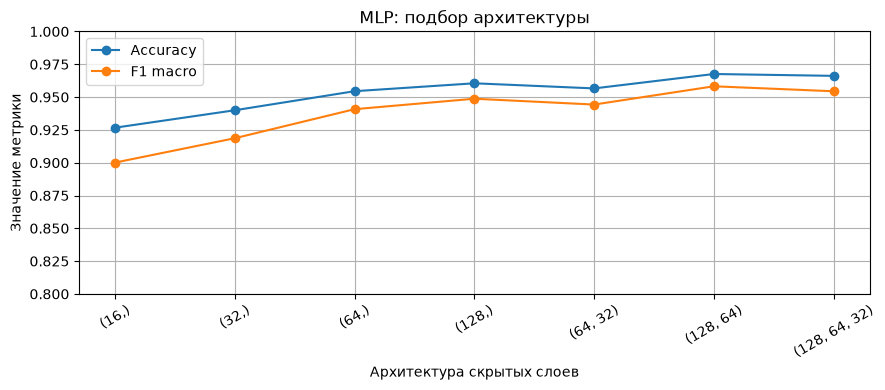

Лучшая архитектура: (128, 64)


hidden_layer_sizes    (128, 64)
train_accuracy         0.985346
eval_accuracy          0.967593
train_f1_macro         0.980828
eval_f1_macro          0.958233
fit_time_sec            5.29921
predict_time_ms        0.000991
Name: 5, dtype: object

In [133]:
plt.figure(figsize=(9, 4))
plt.plot(mlp_architecture_df["hidden_layer_sizes"], mlp_architecture_df["eval_accuracy"], marker="o", label="Accuracy")
plt.plot(mlp_architecture_df["hidden_layer_sizes"], mlp_architecture_df["eval_f1_macro"], marker="o", label="F1 macro")
plt.title("MLP: подбор архитектуры")
plt.xlabel("Архитектура скрытых слоев")
plt.ylabel("Значение метрики")
plt.ylim(0.8, 1)
plt.grid(True)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mlp_architecture_validation.png", dpi=150, bbox_inches="tight")
plt.show()
best_mlp_row = mlp_architecture_df.sort_values(["eval_f1_macro", "eval_accuracy"], ascending=False).iloc[0]
best_mlp_architecture = eval(best_mlp_row["hidden_layer_sizes"])
print("Лучшая архитектура:", best_mlp_architecture)
best_mlp_row


### Вывод
 
 Для MLP были проверены разные архитектуры скрытых слоев: один слой на 16, 32, 64 и 128 нейронов, два слоя `(64, 32)` и `(128, 64)`, а также вариант с тремя слоями `(128, 64, 32)`.
 
 Лучший результат на validation дала архитектура `(128, 64)`: `Accuracy = 0.9676`, `F1 macro = 0.9582`. Вариант с тремя слоями `(128, 64, 32)` тоже показал высокий результат, но оказался немного хуже: `Accuracy = 0.9662`, `F1 macro = 0.9544`.
 
 Значит, добавление третьего скрытого слоя в этом эксперименте не улучшило модель. Для дальнейшей проверки оставлена архитектура `(128, 64)`.


## 7. Финальная проверка лучших моделей на test


In [134]:
best_lr_model = make_lr_model(C=best_lr_C, polynomial_degree=best_lr_degree)
best_mlp_model = make_mlp_model(hidden_layer_sizes=best_mlp_architecture)
lr_test_metrics, lr_test_pred = fit_and_evaluate(best_lr_model, X_full, y_full, X_test, y_test)
mlp_test_metrics, mlp_test_pred = fit_and_evaluate(best_mlp_model, X_full, y_full, X_test, y_test)
final_model_results = pd.DataFrame([
    {"model": "LR", "C": best_lr_C, "polynomial_degree": best_lr_degree, **lr_test_metrics},
    {"model": "MLP", "hidden_layer_sizes": str(best_mlp_architecture), **mlp_test_metrics},
])
final_model_results


,model,C,polynomial_degree,train_accuracy,train_f1_macro,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,fit_time_sec,predict_time_ms,hidden_layer_sizes
0,LR,1.0,2.0,0.939647,0.929371,0.841281,0.793207,0.847421,0.808415,5.235766,0.003781,NaN
1,MLP,NaN,NaN,0.988135,0.984069,0.855329,0.818828,0.843216,0.823197,7.210749,0.001262,"(128, 64)"


In [135]:
print("Logistic Regression")
print(classification_report(y_test, lr_test_pred, zero_division=0))
print("MLP")
print(classification_report(y_test, mlp_test_pred, zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

           0       0.45      0.76      0.57       657
           1       0.92      0.83      0.87      2078
           2       0.90      0.79      0.84       328
           3       0.78      1.00      0.87       265
           4       0.91      0.85      0.88      4075

    accuracy                           0.84      7403
   macro avg       0.79      0.85      0.81      7403
weighted avg       0.87      0.84      0.85      7403

MLP
              precision    recall  f1-score   support

           0       0.51      0.70      0.59       657
           1       0.92      0.84      0.88      2078
           2       0.98      0.79      0.88       328
           3       0.78      1.00      0.88       265
           4       0.90      0.88      0.89      4075

    accuracy                           0.86      7403
   macro avg       0.82      0.84      0.82      7403
weighted avg       0.87      0.86      0.86      7403

### Вывод

Лучшие модели были обучены на всей обучающей выборке и проверены на test. На test логистическая регрессия с полиномиальными признаками дала `Accuracy = 0.8413` и `F1 macro = 0.8084`.

MLP с архитектурой `(128, 64)` дала `Accuracy = 0.8553` и `F1 macro = 0.8232`. По этим значениям MLP оказалась немного лучше логистической регрессии.


## 8. Проверка переобучения


In [136]:
overfitting_check = final_model_results[["model", "train_accuracy", "eval_accuracy", "train_f1_macro", "eval_f1_macro"]].copy()
overfitting_check["accuracy_gap"] = overfitting_check["train_accuracy"] - overfitting_check["eval_accuracy"]
overfitting_check["f1_macro_gap"] = overfitting_check["train_f1_macro"] - overfitting_check["eval_f1_macro"]
overfitting_check


,model,train_accuracy,eval_accuracy,train_f1_macro,eval_f1_macro,accuracy_gap,f1_macro_gap
0,LR,0.939647,0.841281,0.929371,0.808415,0.098367,0.120956
1,MLP,0.988135,0.855329,0.984069,0.823197,0.132806,0.160872


### Вывод

Есть признаки переобучения у обеих моделей. У логистической регрессии `F1 macro` на train равен `0.9294`, а на test — `0.8084`, разница около `0.1210`.

У MLP разница еще больше: `F1 macro` на train равен `0.9841`, а на test — `0.8232`, разница `0.1609`.


## 9. Матрицы ошибок лучших моделей


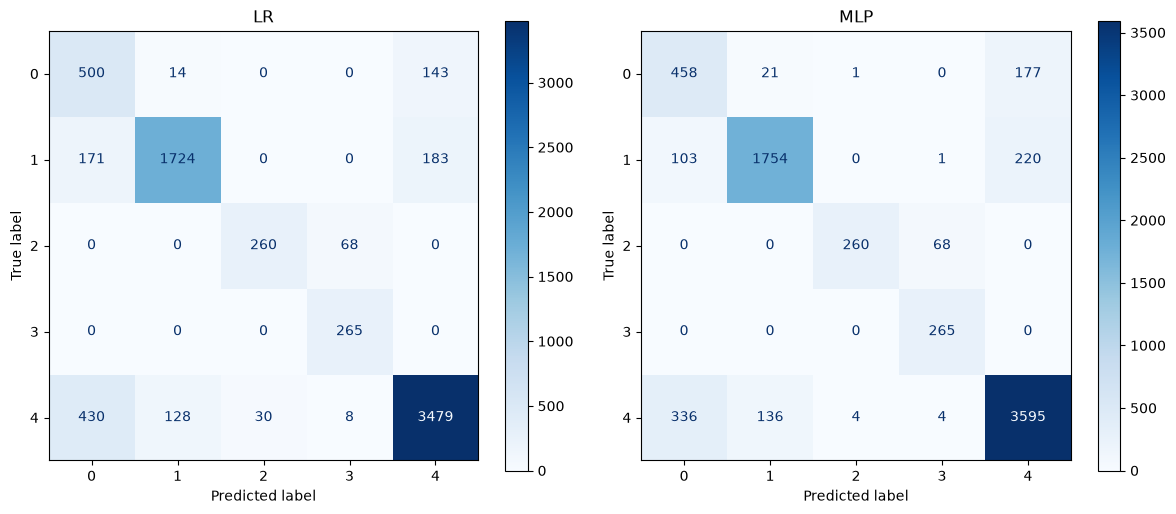

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, lr_test_pred, display_labels=sorted(y_test.unique()), cmap="Blues", values_format="d", ax=axes[0])
axes[0].set_title("LR")
ConfusionMatrixDisplay.from_predictions(y_test, mlp_test_pred, display_labels=sorted(y_test.unique()), cmap="Blues", values_format="d", ax=axes[1])
axes[1].set_title("MLP")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "validation_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Важность всех 24 признаков


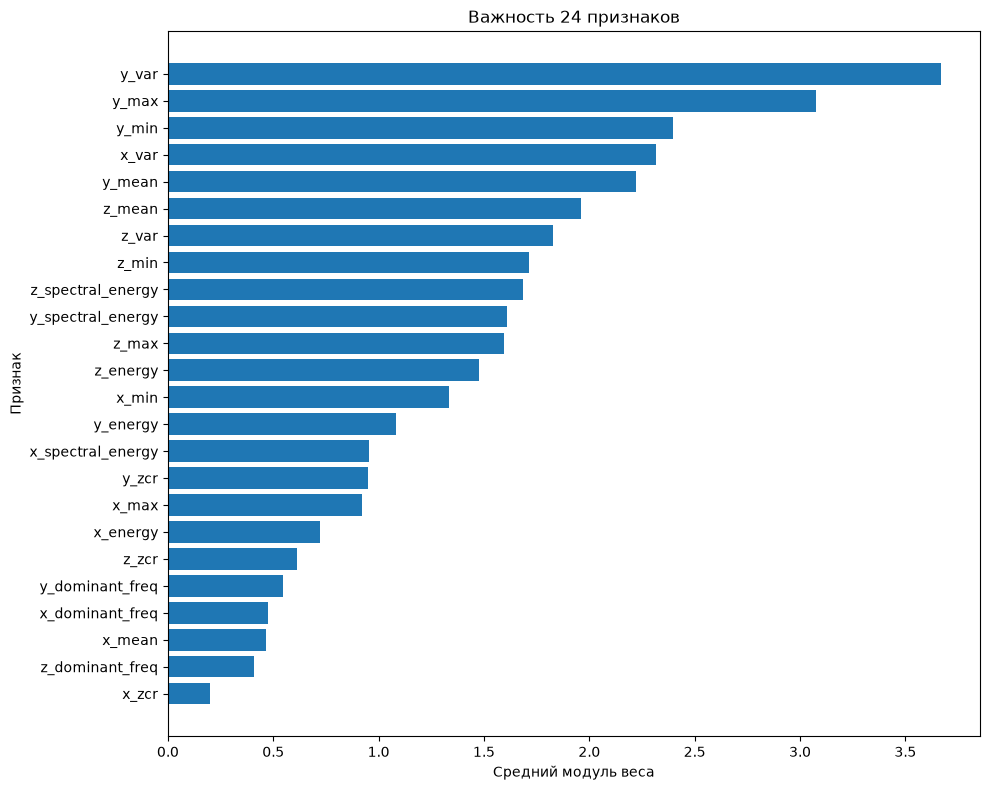

,feature,importance
9,y_var,3.670680
10,y_max,3.077939
11,y_min,2.394822
1,x_var,2.314957
8,y_mean,2.222651
16,z_mean,1.960000
17,z_var,1.826585
19,z_min,1.713238
22,z_spectral_energy,1.683511
14,y_spectral_energy,1.608125


In [146]:
lr_linear_for_importance = make_lr_model(C=best_lr_C, polynomial_degree=1)
lr_linear_for_importance.fit(X_full, y_full)
ovr_model = lr_linear_for_importance.named_steps["model"]
weights = np.array([estimator.coef_[0] for estimator in ovr_model.estimators_])
feature_importance = np.mean(np.abs(weights), axis=0)
feature_importance_df = pd.DataFrame({"feature": X_full.columns, "importance": feature_importance}).sort_values("importance", ascending=False)
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df["feature"][::-1], feature_importance_df["importance"][::-1])
plt.title("Важность 24 признаков")
plt.xlabel("Средний модуль веса")
plt.ylabel("Признак")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lr_all_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
feature_importance_df


In [147]:
dft_features = feature_importance_df[feature_importance_df["feature"].str.contains("spectral_energy|dominant_freq", regex=True)]
most_important_dft_feature = dft_features.iloc[0]
print("Самый важный признак, связанный с ДФТ:")
print(most_important_dft_feature)


Самый важный признак, связанный с ДФТ:
feature       z_spectral_energy
importance             1.683511
Name: 22, dtype: object


### Вывод

Построен график важности всех 24 признаков для логистической регрессии. По нему можно выбирать границу отсечения признаков.

Самый важный признак, связанный с ДФТ, — `z_spectral_energy`. Он показывает энергию частотных составляющих сигнала по оси `z`.


## 11. Перебор top-k признаков от 1 до 24


In [140]:
REPEAT_SEEDS = [0, 1, 2]

def run_topk_experiment(model_factory, ranked_features, model_name, seeds=REPEAT_SEEDS):
    rows = []
    for seed in seeds:
        X_train_rep, X_val_rep, y_train_rep, y_val_rep = train_test_split(
            X_full,
            y_full,
            test_size=0.2,
            random_state=seed,
            stratify=y_full,
        )
        for k in range(1, len(ranked_features) + 1):
            selected_features = ranked_features[:k]
            model = model_factory(seed)
            metrics, _ = fit_and_evaluate(
                model,
                X_train_rep[selected_features],
                y_train_rep,
                X_val_rep[selected_features],
                y_val_rep,
            )
            rows.append({"model": model_name, "seed": seed, "k": k, "features": selected_features, **metrics})
    return pd.DataFrame(rows)

def summarize_topk_runs(topk_runs_df):
    summary = topk_runs_df.groupby(["model", "k"], as_index=False).agg(
        eval_accuracy_mean=("eval_accuracy", "mean"),
        eval_accuracy_std=("eval_accuracy", "std"),
        eval_f1_macro_mean=("eval_f1_macro", "mean"),
        eval_f1_macro_std=("eval_f1_macro", "std"),
        predict_time_ms_mean=("predict_time_ms", "mean"),
    )
    return summary.fillna(0)

ranked_lr_features = feature_importance_df["feature"].tolist()
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_full, y_full)
select_kbest_scores = pd.DataFrame({"feature": X_full.columns, "score": selector.scores_}).sort_values("score", ascending=False)
ranked_mlp_features = select_kbest_scores["feature"].tolist()

lr_topk_runs_df = run_topk_experiment(lambda seed: make_lr_model(C=best_lr_C, polynomial_degree=1, random_state=seed), ranked_lr_features, "LR")
mlp_topk_runs_df = run_topk_experiment(lambda seed: make_mlp_model(hidden_layer_sizes=best_mlp_architecture, random_state=seed), ranked_mlp_features, "MLP")
lr_topk_df = summarize_topk_runs(lr_topk_runs_df)
mlp_topk_df = summarize_topk_runs(mlp_topk_runs_df)

pd.concat([
    lr_topk_df[["model", "k", "eval_accuracy_mean", "eval_accuracy_std", "eval_f1_macro_mean", "eval_f1_macro_std"]],
    mlp_topk_df[["model", "k", "eval_accuracy_mean", "eval_accuracy_std", "eval_f1_macro_mean", "eval_f1_macro_std"]],
], ignore_index=True)

,model,k,eval_accuracy_mean,eval_accuracy_std,eval_f1_macro_mean,eval_f1_macro_std
0,LR,1,0.774807,0.000271,0.477330,0.000208
1,LR,2,0.810814,0.004192,0.697461,0.006376
2,LR,3,0.822915,0.002609,0.702443,0.004386
3,LR,4,0.826397,0.003656,0.699650,0.003804
4,LR,5,0.811877,0.004225,0.713458,0.004988
5,LR,6,0.816953,0.004074,0.782789,0.008073
6,LR,7,0.821144,0.002783,0.786617,0.006424
7,LR,8,0.825630,0.002531,0.805164,0.004450
8,LR,9,0.834366,0.001256,0.821335,0.002134
9,LR,10,0.839738,0.001383,0.826562,0.000804


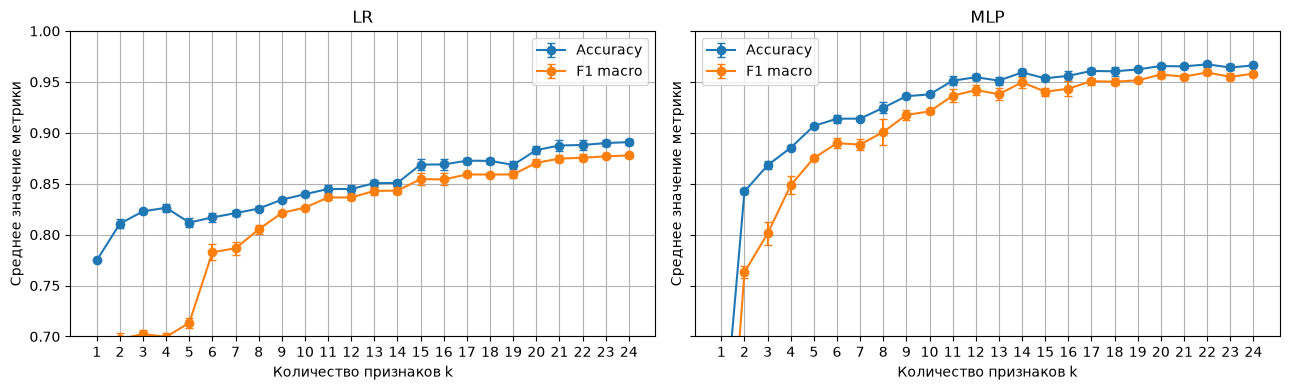

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, df, title in [(axes[0], lr_topk_df, "LR"), (axes[1], mlp_topk_df, "MLP")]:
    ax.errorbar(df["k"], df["eval_accuracy_mean"], yerr=df["eval_accuracy_std"], marker="o", capsize=3, label="Accuracy")
    ax.errorbar(df["k"], df["eval_f1_macro_mean"], yerr=df["eval_f1_macro_std"], marker="o", capsize=3, label="F1 macro")
    ax.set_title(title)
    ax.set_xlabel("Количество признаков k")
    ax.set_ylabel("Среднее значение метрики")
    ax.set_xticks(range(1, 25))
    ax.set_ylim(0.7, 1.0)
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topk_metrics_1_to_24.png", dpi=150, bbox_inches="tight")
plt.show()

### Вывод
 
 Перебор количества признаков выполнен несколько раз с разными `random_state`: `0`, `1`, `2`. Поэтому в таблице и на графике показано не одно случайное значение, а среднее значение метрики и стандартное отклонение.
 
 По графику видно, что качество LR постепенно растет при увеличении числа признаков и максимум достигается около полного набора. Для MLP качество быстро растет после первых признаков, а затем изменения становятся небольшими. Поэтому маленькие отличия между соседними `k` нужно считать осторожно: они могут быть связаны с разбросом между запусками.


## 12. Выбор границы отсечения признаков


In [154]:
QUALITY_EPS = 0.001

def choose_k_by_threshold(topk_df):
    full_row = topk_df[topk_df["k"] == 24].iloc[0]
    candidates = topk_df[
        (topk_df["eval_accuracy_mean"] >= full_row["eval_accuracy_mean"] - QUALITY_EPS)
        & (topk_df["eval_f1_macro_mean"] >= full_row["eval_f1_macro_mean"] - QUALITY_EPS)
    ]
    if len(candidates) == 0:
        best_row = topk_df.sort_values(["eval_f1_macro_mean", "eval_accuracy_mean"], ascending=False).iloc[0]
        return int(best_row["k"]), "нет k в пределах порога, выбран лучший по среднему F1 macro"
    best_row = candidates.sort_values("k").iloc[0]
    return int(best_row["k"]), "среднее качество почти не хуже полного набора"

best_lr_k, lr_k_reason = choose_k_by_threshold(lr_topk_df)
best_mlp_k, mlp_k_reason = choose_k_by_threshold(mlp_topk_df)
print("LR: k =", best_lr_k, "-", lr_k_reason)
print("MLP: k =", best_mlp_k, "-", mlp_k_reason)

LR: k = 24 - среднее качество почти не хуже полного набора
MLP: k = 20 - среднее качество почти не хуже полного набора


In [155]:
def compare_k_minus_one(topk_df, selected_k):
    ks = sorted(set([24, selected_k, max(1, selected_k - 1)]))
    columns = [
        "model", "k",
        "eval_accuracy_mean", "eval_accuracy_std",
        "eval_f1_macro_mean", "eval_f1_macro_std",
        "predict_time_ms_mean",
    ]
    return topk_df[topk_df["k"].isin(ks)][columns].sort_values("k")

feature_cutoff_comparison = pd.concat([
    compare_k_minus_one(lr_topk_df, best_lr_k),
    compare_k_minus_one(mlp_topk_df, best_mlp_k),
], ignore_index=True)
feature_cutoff_comparison

,model,k,eval_accuracy_mean,eval_accuracy_std,eval_f1_macro_mean,eval_f1_macro_std,predict_time_ms_mean
0,LR,23,0.889912,0.002745,0.876875,0.001695,0.000445
1,LR,24,0.890916,0.002783,0.877807,0.002056,0.000520
2,MLP,19,0.962281,0.000638,0.951549,0.000296,0.001433
3,MLP,20,0.965586,0.002098,0.957236,0.003038,0.001686
4,MLP,24,0.966177,0.000177,0.958110,0.002079,0.001713


### Вывод
 
 Граница отсечения выбиралась по средним значениям метрик на validation с порогом `0.001`. После повторных запусков для LR был выбран полный набор `k = 24`, потому что при `k = 23` средние метрики немного ниже: `Accuracy = 0.8899 ± 0.0027`, `F1 macro = 0.8769 ± 0.0017`, а при `k = 24`: `Accuracy = 0.8909 ± 0.0028`, `F1 macro = 0.8778 ± 0.0021`.
 
 Для MLP на validation выбран вариант `k = 20`. Он почти не отличается от полного набора: при `k = 20` получено `Accuracy = 0.9656 ± 0.0021`, `F1 macro = 0.9572 ± 0.0030`; при `k = 24` — `Accuracy = 0.9662 ± 0.0002`, `F1 macro = 0.9581 ± 0.0021`. При `k = 19` качество уже ниже: `Accuracy = 0.9623 ± 0.0006`, `F1 macro = 0.9515 ± 0.0003`.
 
 Итог по validation: для LR оставляется `24` признака, а для MLP фиксируется `20` признаков. Дальше эти выбранные варианты проверяются на test, но сам выбор модели уже не меняется по test.


## 13. Финальная проверка выбранных top-k на test


In [158]:
def final_test_for_k(model_factory, ranked_features, k, model_name):
    selected = ranked_features[:k]
    model = model_factory()
    metrics, pred = fit_and_evaluate(model, X_full[selected], y_full, X_test[selected], y_test)
    return {"model": model_name, "k": k, "features": selected, **metrics}, pred

lr_final_test = {"model": "LR poly degree 2", "k": 24, **lr_test_metrics}
mlp_final_test, mlp_best_k_pred = final_test_for_k(
    lambda: make_mlp_model(hidden_layer_sizes=best_mlp_architecture, random_state=42),
    ranked_mlp_features,
    best_mlp_k,
    "MLP selected features",
)
final_topk_test_results = pd.DataFrame([lr_final_test, mlp_final_test])
final_topk_test_results[["model", "k", "eval_accuracy", "eval_precision_macro", "eval_recall_macro", "eval_f1_macro", "predict_time_ms"]]

,model,k,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,predict_time_ms
0,LR poly degree 2,24,0.841281,0.793207,0.847421,0.808415,0.003781
1,MLP selected features,20,0.854383,0.811203,0.822226,0.812579,0.001411


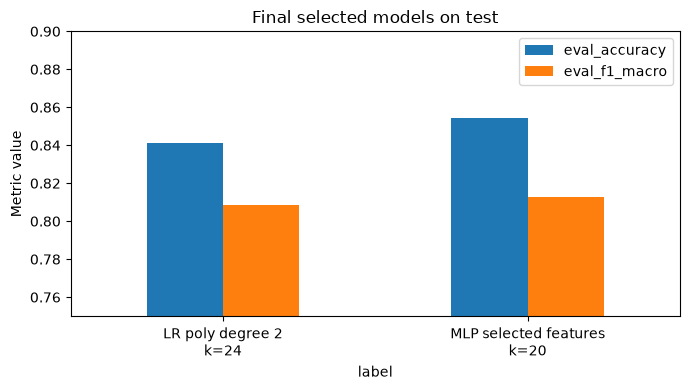

In [159]:
plot_df = final_topk_test_results.copy()
plot_df["label"] = plot_df["model"] + "\nk=" + plot_df["k"].astype(str)
plot_df.set_index("label")[["eval_accuracy", "eval_f1_macro"]].plot(kind="bar", figsize=(7, 4))
plt.title("Final selected models on test")
plt.ylabel("Metric value")
plt.ylim(0.75, 0.9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_validation_results.png", dpi=150, bbox_inches="tight")
plt.show()

### Вывод
 
 В финальной таблице оставлены только две выбранные модели. Для LR это логистическая регрессия с полиномиальными признаками степени 2 и полным набором из `24` исходных признаков. Для MLP это модель с выбранными `20` признаками, потому что этот вариант был зафиксирован на этапе validation.
 
 На test логистическая регрессия дала `Accuracy = 0.8413`, `F1 macro = 0.8084`. MLP с `20` признаками дала `Accuracy = 0.8544`, `F1 macro = 0.8126`.
 
 Итог: из двух финальных моделей лучшее качество на test показала MLP с `20` выбранными признаками. При этом важно, что выбор `20` признаков был сделан на validation, а test использовался только для финальной проверки качества.
